In [1]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import io
import json
import warnings
warnings.filterwarnings('ignore')

from arch import arch_model

def query_athena(query, database='fx_rates_db', region='us-east-2'):
    athena = boto3.client('athena', region_name=region)
    s3 = boto3.client('s3', region_name=region)
    output_location = 's3://fx-rates-ninpar/athena-results/'
    
    response = athena.start_query_execution(
        QueryString=query,
        QueryExecutionContext={'Database': database},
        ResultConfiguration={'OutputLocation': output_location}
    )
    query_id = response['QueryExecutionId']
    
    while True:
        status = athena.get_query_execution(QueryExecutionId=query_id)
        state = status['QueryExecution']['Status']['State']
        if state in ['SUCCEEDED', 'FAILED', 'CANCELLED']:
            break
        time.sleep(1)
    
    if state != 'SUCCEEDED':
        raise Exception(f"Query failed: {status['QueryExecution']['Status'].get('StateChangeReason')}")
    
    result_location = status['QueryExecution']['ResultConfiguration']['OutputLocation']
    bucket = result_location.split('/')[2]
    key = '/'.join(result_location.split('/')[3:])
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(obj['Body'].read()))

df = query_athena("""
    SELECT date, rates.inr AS usd_inr, rates.eur AS usd_eur, 
           rates.gbp AS usd_gbp, rates.mxn AS usd_mxn, rates.php AS usd_php
    FROM fx_rates_db.usd
    ORDER BY date ASC
""")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

# Returns in percentage form (GARCH convention)
returns = df.pct_change().dropna() * 100

print(f"Loaded {len(df)} trading days")
print(f"Returns range: {returns.index.min()} to {returns.index.max()}")

Loaded 281 trading days
Returns range: 2025-05-02 00:00:00 to 2026-06-05 00:00:00


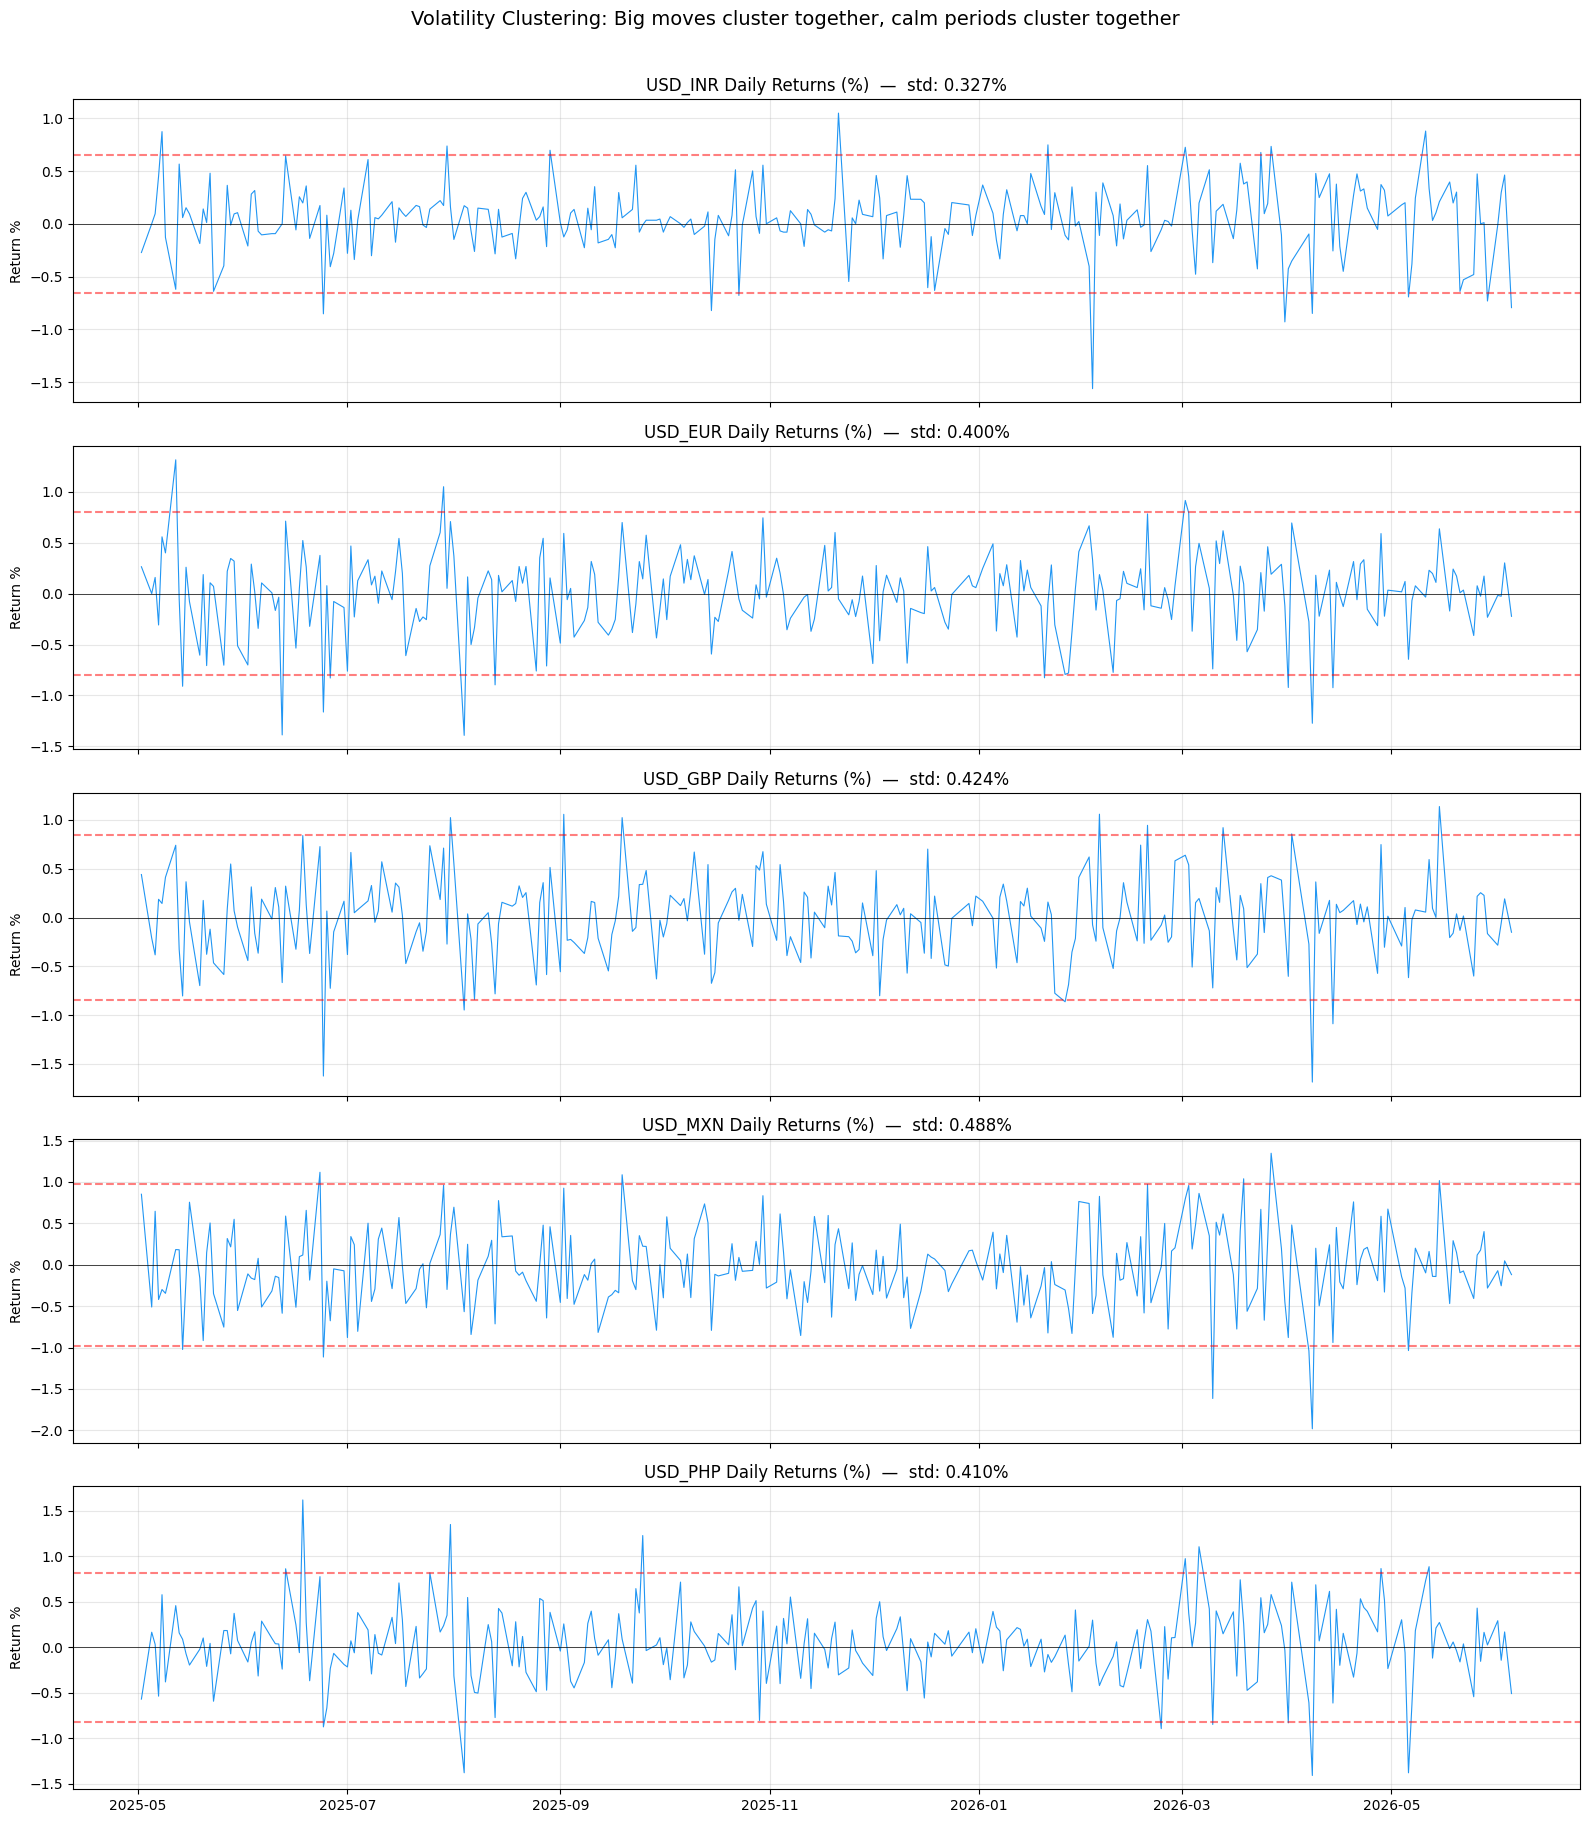

Notice: large absolute returns tend to cluster — a turbulent week is followed
by another turbulent week, a calm period stays calm. This is what GARCH exploits.
If returns were truly random, you'd see uniform spread of large and small moves.


In [2]:
fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)

for i, col in enumerate(['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']):
    r = returns[col].dropna()
    
    axes[i].plot(r.index, r.values, color='#2196F3', linewidth=0.8)
    axes[i].axhline(0, color='black', linewidth=0.5)
    
    # Add ±2 std bands
    std = r.std()
    axes[i].axhline(2*std, color='red', linestyle='--', alpha=0.5)
    axes[i].axhline(-2*std, color='red', linestyle='--', alpha=0.5)
    
    axes[i].set_title(f'{col.upper()} Daily Returns (%)  —  std: {std:.3f}%', fontsize=12)
    axes[i].set_ylabel('Return %')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Volatility Clustering: Big moves cluster together, calm periods cluster together', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('volatility_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print("Notice: large absolute returns tend to cluster — a turbulent week is followed")
print("by another turbulent week, a calm period stays calm. This is what GARCH exploits.")
print("If returns were truly random, you'd see uniform spread of large and small moves.")

In [3]:
from arch.unitroot import ADF
from statsmodels.stats.diagnostic import het_arch

print("=== ARCH Effect Test ===\n")
print("Tests whether volatility is autocorrelated (clusters).\n")
print("H0: no ARCH effects (volatility is random)")
print("If p-value < 0.05, reject H0 → volatility IS forecastable\n")

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    r = returns[col].dropna()
    
    # Lagrange Multiplier test for ARCH effects
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(r, nlags=5)
    
    result = "✓ ARCH effects DETECTED" if lm_pvalue < 0.05 else "✗ no significant ARCH effects"
    
    print(f"{col.upper()}:")
    print(f"  LM statistic: {lm_stat:.4f}")
    print(f"  p-value: {lm_pvalue:.4f}")
    print(f"  {result}")
    print()

print("Currencies with ARCH effects are good candidates for GARCH modeling.")

=== ARCH Effect Test ===

Tests whether volatility is autocorrelated (clusters).

H0: no ARCH effects (volatility is random)
If p-value < 0.05, reject H0 → volatility IS forecastable

USD_INR:
  LM statistic: 0.5576
  p-value: 0.9899
  ✗ no significant ARCH effects

USD_EUR:
  LM statistic: 5.2714
  p-value: 0.3837
  ✗ no significant ARCH effects

USD_GBP:
  LM statistic: 5.8122
  p-value: 0.3249
  ✗ no significant ARCH effects

USD_MXN:
  LM statistic: 5.3090
  p-value: 0.3793
  ✗ no significant ARCH effects

USD_PHP:
  LM statistic: 14.6174
  p-value: 0.0121
  ✓ ARCH effects DETECTED

Currencies with ARCH effects are good candidates for GARCH modeling.


In [4]:
# Fit GARCH(1,1) with Student-t errors on USD/INR
# GARCH(1,1) is the standard — 1 lag of returns squared, 1 lag of variance
# Student-t handles fat tails (FX returns aren't normally distributed)

r_inr = returns['usd_inr'].dropna()

model = arch_model(r_inr, vol='GARCH', p=1, q=1, dist='t')
result = model.fit(disp='off')

print("=== GARCH(1,1) Model for USD/INR ===\n")
print(result.summary())

=== GARCH(1,1) Model for USD/INR ===

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                      usd_inr   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -62.3997
Distribution:      Standardized Student's t   AIC:                           134.799
Method:                  Maximum Likelihood   BIC:                           152.956
                                              No. Observations:                  279
Date:                      Mon, Jun 08 2026   Df Residuals:                      278
Time:                              15:01:52   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
-------------------------------------------

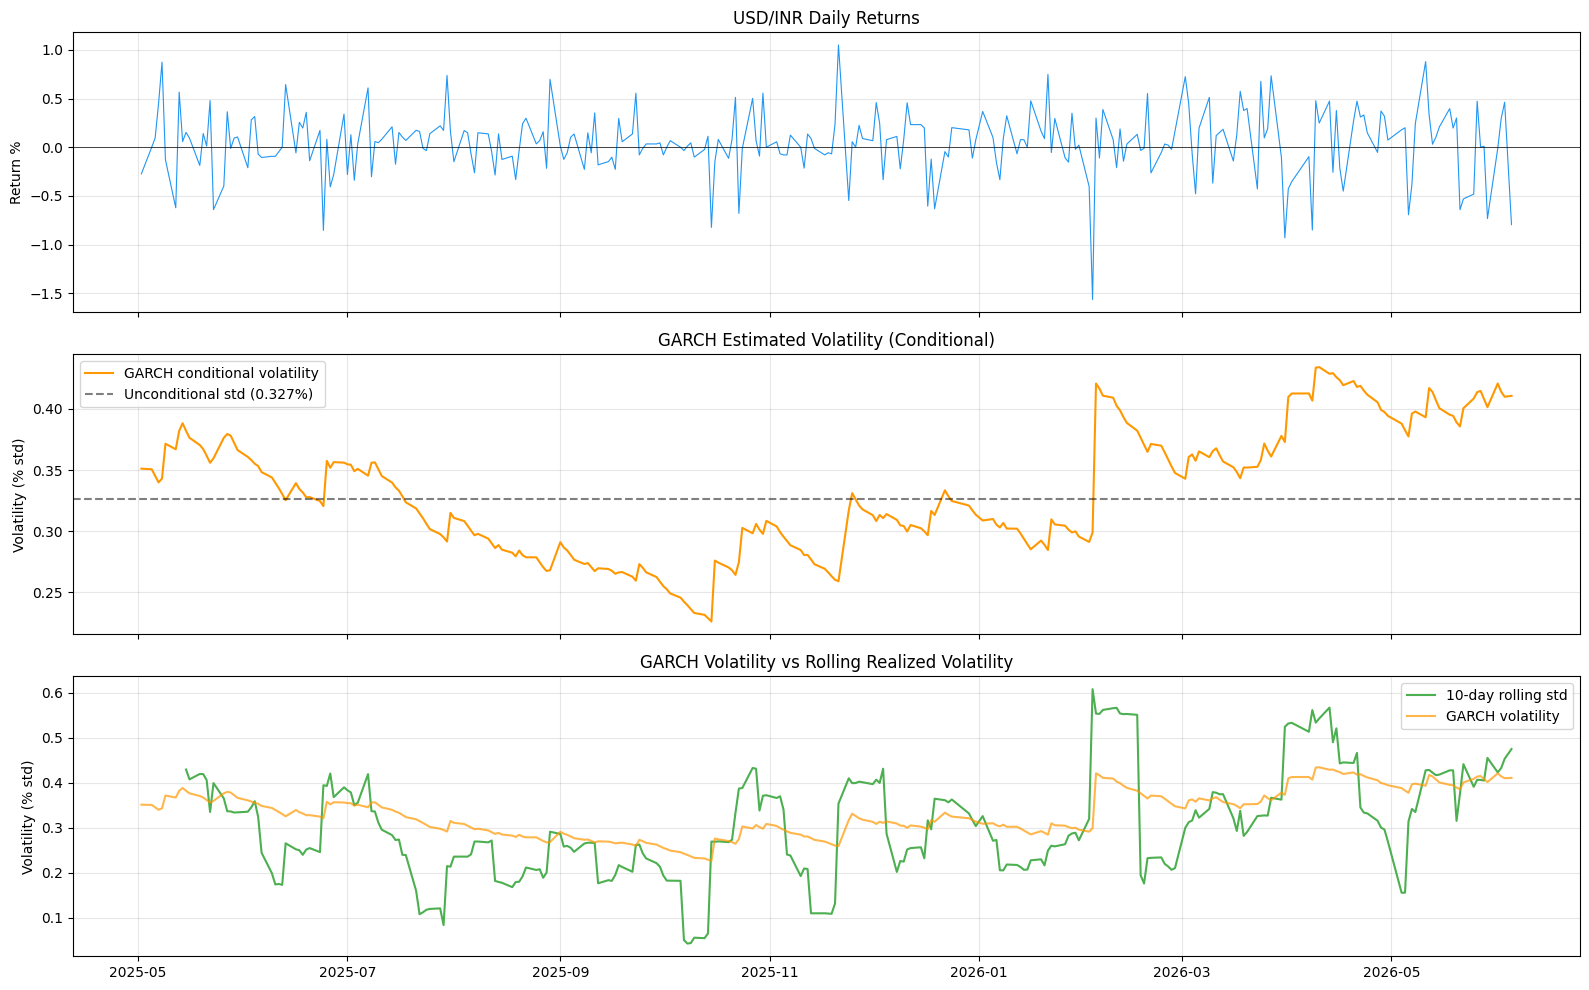

GARCH (orange) tracks realized volatility (green) closely.
During calm periods both are low; during turbulent periods both spike.
GARCH provides a forward-looking estimate — it forecasts tomorrow's volatility.


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

r = returns['usd_inr'].dropna()
fitted_vol = result.conditional_volatility

# Panel 1: returns
axes[0].plot(r.index, r.values, color='#2196F3', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('USD/INR Daily Returns', fontsize=12)
axes[0].set_ylabel('Return %')
axes[0].grid(True, alpha=0.3)

# Panel 2: fitted GARCH volatility
axes[1].plot(fitted_vol.index, fitted_vol.values, color='#FF9800', linewidth=1.5, label='GARCH conditional volatility')
axes[1].axhline(r.std(), color='black', linestyle='--', alpha=0.5, label=f'Unconditional std ({r.std():.3f}%)')
axes[1].set_title('GARCH Estimated Volatility (Conditional)', fontsize=12)
axes[1].set_ylabel('Volatility (% std)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: rolling 10-day realized volatility for comparison
realized_vol = r.rolling(10).std()
axes[2].plot(realized_vol.index, realized_vol.values, color='#4CAF50', linewidth=1.5, label='10-day rolling std')
axes[2].plot(fitted_vol.index, fitted_vol.values, color='#FF9800', linewidth=1.5, alpha=0.7, label='GARCH volatility')
axes[2].set_title('GARCH Volatility vs Rolling Realized Volatility', fontsize=12)
axes[2].set_ylabel('Volatility (% std)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('garch_volatility_inr.png', dpi=150, bbox_inches='tight')
plt.show()

print("GARCH (orange) tracks realized volatility (green) closely.")
print("During calm periods both are low; during turbulent periods both spike.")
print("GARCH provides a forward-looking estimate — it forecasts tomorrow's volatility.")

In [6]:
def walk_forward_garch(returns_series, test_days=60, horizon=1):
    """
    Walk-forward GARCH evaluation.
    For each test day, fit GARCH on prior data, forecast volatility,
    compare to actual realized volatility.
    """
    r = returns_series.dropna()
    
    if len(r) < test_days + 90:
        return None
    
    results = []
    
    for i in range(test_days, 0, -1):
        train = r[:-i]
        
        # Fit GARCH(1,1)
        try:
            model = arch_model(train, vol='GARCH', p=1, q=1, dist='t')
            fit = model.fit(disp='off', show_warning=False)
            
            # Forecast volatility for next day
            forecast = fit.forecast(horizon=horizon, reindex=False)
            forecast_variance = forecast.variance.values[-1, 0]
            forecast_vol = np.sqrt(forecast_variance)
            
            # Actual return on the forecast day
            actual_return = r.iloc[-i]
            actual_squared_return = actual_return ** 2
            actual_vol = abs(actual_return)  # absolute return as proxy for realized vol
            
            # Naive baseline: yesterday's absolute return predicts today's vol
            naive_vol = abs(train.iloc[-1])
            
            # Long-run baseline: historical std
            historical_vol = train.std()
            
            results.append({
                'date': r.index[-i],
                'actual_return': actual_return,
                'actual_vol': actual_vol,
                'garch_vol': forecast_vol,
                'naive_vol': naive_vol,
                'historical_vol': historical_vol,
                'garch_squared_error': (actual_squared_return - forecast_variance) ** 2,
                'naive_squared_error': (actual_squared_return - naive_vol**2) ** 2,
                'historical_squared_error': (actual_squared_return - historical_vol**2) ** 2
            })
        except Exception as e:
            continue
    
    return pd.DataFrame(results)

print("Running walk-forward GARCH evaluation...")
print("(faster than Prophet — GARCH fits in seconds)\n")

garch_evaluation = {}

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    print(f"  {col.upper()}...", end=" ", flush=True)
    result = walk_forward_garch(returns[col], test_days=60)
    if result is not None and len(result) > 0:
        garch_evaluation[col] = result
        print(f"done — {len(result)} forecasts")
    else:
        print("skipped")

print("\nGARCH evaluation complete")

Running walk-forward GARCH evaluation...
(faster than Prophet — GARCH fits in seconds)

  USD_INR... done — 60 forecasts
  USD_EUR... done — 60 forecasts
  USD_GBP... done — 60 forecasts
  USD_MXN... done — 60 forecasts
  USD_PHP... done — 60 forecasts

GARCH evaluation complete


In [7]:
print("=== GARCH vs Baselines (Proper Theil's U2) ===\n")

comparison_rows = []

for col, result in garch_evaluation.items():
    # Convert MSE → RMSE by sqrt
    garch_rmse = result['garch_squared_error'].mean() ** 0.5
    naive_rmse = result['naive_squared_error'].mean() ** 0.5
    historical_rmse = result['historical_squared_error'].mean() ** 0.5
    
    theil_u_naive = garch_rmse / naive_rmse
    theil_u_historical = garch_rmse / historical_rmse
    
    comparison_rows.append({
        'pair': col.upper(),
        'garch_rmse': garch_rmse,
        'naive_rmse': naive_rmse,
        'historical_rmse': historical_rmse,
        'theil_u_vs_naive': theil_u_naive,
        'theil_u_vs_hist': theil_u_historical,
        'verdict': 'GARCH WINS' if (theil_u_naive < 0.95 and theil_u_historical < 0.95) 
                   else 'GARCH OK' if (theil_u_naive < 1.05 and theil_u_historical < 1.05)
                   else 'GARCH LOSES'
    })

comparison_df = pd.DataFrame(comparison_rows).set_index('pair')
print(comparison_df.round(4).to_string())

print(f"\n=== Interpretation ===")
print(f"theil_u_vs_naive: GARCH error / yesterday's-return baseline")
print(f"theil_u_vs_hist:  GARCH error / historical-std baseline")
print(f"GARCH WINS:       beats BOTH baselines by >5%")

=== GARCH vs Baselines (Proper Theil's U2) ===

         garch_rmse  naive_rmse  historical_rmse  theil_u_vs_naive  theil_u_vs_hist   verdict
pair                                                                                         
USD_INR      0.2137      0.2994           0.2179            0.7139           0.9808  GARCH OK
USD_EUR      0.2718      0.3890           0.2702            0.6988           1.0062  GARCH OK
USD_GBP      0.4392      0.6429           0.4388            0.6832           1.0010  GARCH OK
USD_MXN      0.6638      0.9195           0.6730            0.7219           0.9864  GARCH OK
USD_PHP      0.3859      0.5042           0.3896            0.7654           0.9904  GARCH OK

=== Interpretation ===
theil_u_vs_naive: GARCH error / yesterday's-return baseline
theil_u_vs_hist:  GARCH error / historical-std baseline
GARCH WINS:       beats BOTH baselines by >5%


In [8]:
print("=== GARCH Performance by Volatility Regime ===\n")
print("Does GARCH work better when markets are turbulent?\n")

for col, result in garch_evaluation.items():
    # Split by GARCH's predicted volatility
    high_vol_threshold = result['garch_vol'].quantile(0.75)
    low_vol_threshold = result['garch_vol'].quantile(0.25)
    
    high_vol = result[result['garch_vol'] > high_vol_threshold]
    low_vol = result[result['garch_vol'] < low_vol_threshold]
    
    if len(high_vol) == 0 or len(low_vol) == 0:
        continue
    
    high_garch_mse = high_vol['garch_squared_error'].mean()
    high_naive_mse = high_vol['naive_squared_error'].mean()
    
    low_garch_mse = low_vol['garch_squared_error'].mean()
    low_naive_mse = low_vol['naive_squared_error'].mean()
    
    print(f"{col.upper()}:")
    print(f"  High-vol regime (top 25%):  Theil U = {high_garch_mse/high_naive_mse:.3f}  ({len(high_vol)} days)")
    print(f"  Low-vol regime (bottom 25%): Theil U = {low_garch_mse/low_naive_mse:.3f}  ({len(low_vol)} days)")
    print()

print("If high-vol Theil U < low-vol Theil U, GARCH is more useful when it matters most.")

=== GARCH Performance by Volatility Regime ===

Does GARCH work better when markets are turbulent?

USD_INR:
  High-vol regime (top 25%):  Theil U = 0.162  (15 days)
  Low-vol regime (bottom 25%): Theil U = 0.747  (15 days)

USD_EUR:
  High-vol regime (top 25%):  Theil U = 0.189  (15 days)
  Low-vol regime (bottom 25%): Theil U = 0.639  (15 days)

USD_GBP:
  High-vol regime (top 25%):  Theil U = 0.033  (15 days)
  Low-vol regime (bottom 25%): Theil U = 0.792  (15 days)

USD_MXN:
  High-vol regime (top 25%):  Theil U = 0.512  (15 days)
  Low-vol regime (bottom 25%): Theil U = 0.908  (15 days)

USD_PHP:
  High-vol regime (top 25%):  Theil U = 0.169  (15 days)
  Low-vol regime (bottom 25%): Theil U = 0.672  (15 days)

If high-vol Theil U < low-vol Theil U, GARCH is more useful when it matters most.


In [9]:
# What's the GARCH-predicted volatility for tomorrow, for each pair?

print("=== Today's Volatility Signal (for product use) ===\n")

product_signals = []

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    r = returns[col].dropna()
    
    # Fit on all data
    model = arch_model(r, vol='GARCH', p=1, q=1, dist='t')
    fit = model.fit(disp='off', show_warning=False)
    
    # Forecast tomorrow's volatility
    forecast = fit.forecast(horizon=5, reindex=False)
    next_5_vol = np.sqrt(forecast.variance.values[-1])
    
    # Compare to historical
    historical_vol = r.std()
    current_vol = fit.conditional_volatility.iloc[-1]
    
    # Percentile of current vol vs historical
    rolling_vol_history = r.rolling(20).std().dropna()
    percentile = (rolling_vol_history < current_vol).mean() * 100
    
    # Signal
    if current_vol > historical_vol * 1.5:
        signal = 'HIGH_VOL'
        advice = 'Consider locking in now via forward / immediate transfer'
    elif current_vol < historical_vol * 0.7:
        signal = 'LOW_VOL'
        advice = 'Calm conditions — you can wait if no deadline pressure'
    else:
        signal = 'NORMAL_VOL'
        advice = 'Normal market conditions'
    
    product_signals.append({
        'pair': col.upper(),
        'current_vol': current_vol,
        'historical_vol': historical_vol,
        'vs_historical': current_vol / historical_vol,
        'percentile': percentile,
        'next_day_forecast': next_5_vol[0],
        'next_5_day_avg': next_5_vol.mean(),
        'signal': signal,
        'advice': advice
    })

signals_df = pd.DataFrame(product_signals).set_index('pair')
print(signals_df.to_string())

print(f"\n=== This is the volatility signal layer of your FX advisor product ===")
print(f"Even if you don't know WHICH direction the rate will move,")
print(f"knowing HOW MUCH it will move is genuinely actionable:")
print(f"  - High volatility + need to transfer = lock in rate now")
print(f"  - Low volatility + flexible timing = safe to wait")
print(f"  - This is what existing FX advisors don't provide")

=== Today's Volatility Signal (for product use) ===

         current_vol  historical_vol  vs_historical  percentile  next_day_forecast  next_5_day_avg      signal                    advice
pair                                                                                                                                    
USD_INR     0.410775        0.326640       1.257577   82.692308           0.433550        0.434581  NORMAL_VOL  Normal market conditions
USD_EUR     0.353551        0.400266       0.883290   41.923077           0.353448        0.353296  NORMAL_VOL  Normal market conditions
USD_GBP     0.424315        0.423916       1.000942   54.615385           0.424315        0.424315  NORMAL_VOL  Normal market conditions
USD_MXN     0.392147        0.488299       0.803087   18.076923           0.383317        0.391308  NORMAL_VOL  Normal market conditions
USD_PHP     0.325217        0.409709       0.793776   31.538462           0.376140        0.386844  NORMAL_VOL  Normal market

In [10]:
garch_output = {}

for col, result in garch_evaluation.items():
    # Convert MSE → RMSE for proper Theil's U2
    garch_rmse = result['garch_squared_error'].mean() ** 0.5
    naive_rmse = result['naive_squared_error'].mean() ** 0.5
    historical_rmse = result['historical_squared_error'].mean() ** 0.5
    
    # Keep MSE values for reference
    garch_mse = result['garch_squared_error'].mean()
    naive_mse = result['naive_squared_error'].mean()
    historical_mse = result['historical_squared_error'].mean()
    
    garch_output[col] = {
        'model': 'garch_1_1_t',
        'test_days': len(result),
        'garch_rmse': float(garch_rmse),
        'naive_rmse': float(naive_rmse),
        'historical_rmse': float(historical_rmse),
        'garch_mse': float(garch_mse),
        'naive_mse': float(naive_mse),
        'historical_mse': float(historical_mse),
        'theil_u_vs_naive': float(garch_rmse / naive_rmse),
        'theil_u_vs_historical': float(garch_rmse / historical_rmse),
        'mse_ratio_vs_naive': float(garch_mse / naive_mse),   # for reference
    }

with open('garch_results.json', 'w') as f:
    json.dump(garch_output, f, indent=2)

print("GARCH results saved with proper Theil's U2")

GARCH results saved with proper Theil's U2
